In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Black vs SABR Swaption Analysis

This notebook compares flat-vol Black pricing with SABR-adjusted pricing for a USD European payer swaption. It also shows a simple SABR calibration workflow on a synthetic smile.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.pricing.european import price_swaption
from swaption_pricing.pricing.european import calibrate_sabr_to_vols
from swaption_pricing.risk import compare_black_and_sabr_risk
from swaption_pricing.pricing.european import SabrParams, price_swaption_with_sabr, sabr_implied_volatility
from swaption_pricing.core import forward_swap_rate
from swaption_pricing.types import CurvePoint, SwaptionSpec

In [3]:
curve = [
    CurvePoint(maturity=1.0, zero_rate=0.0420),
    CurvePoint(maturity=2.0, zero_rate=0.0415),
    CurvePoint(maturity=3.0, zero_rate=0.0410),
    CurvePoint(maturity=4.0, zero_rate=0.0408),
    CurvePoint(maturity=5.0, zero_rate=0.0405),
    CurvePoint(maturity=6.0, zero_rate=0.0403),
    CurvePoint(maturity=7.0, zero_rate=0.0402),
]

expiry = 2.0
tenor = 5.0
pay_frequency = 1
notional = 10_000_000.0
flat_black_vol = 0.20
sabr_params = SabrParams(alpha=0.0200, beta=0.50, rho=-0.25, nu=0.40)
forward = forward_swap_rate(curve, expiry, tenor, pay_frequency)
strikes = [0.0300, 0.0350, 0.0400, 0.0450, 0.0500]
forward

0.040491972814570155

In [4]:
rows = []
for strike in strikes:
    spec = SwaptionSpec(
        notional=notional,
        expiry=expiry,
        tenor=tenor,
        strike=strike,
        pay_frequency=pay_frequency,
        option_type='payer',
    )
    black_price = price_swaption(curve, spec, flat_black_vol)
    sabr_price, sabr_vol = price_swaption_with_sabr(curve, spec, sabr_params)
    rows.append({
        'strike': strike,
        'forward': forward,
        'black_vol': flat_black_vol,
        'sabr_vol': sabr_vol,
        'black_price': black_price,
        'sabr_price': sabr_price,
    })

comparison = pd.DataFrame(rows)
comparison

,strike,forward,black_vol,sabr_vol,black_price,sabr_price
0,0.030,0.040492,0.2,0.137420,458870.790843,436481.942854
1,0.035,0.040492,0.2,0.116788,308312.870103,250956.165399
2,0.040,0.040492,0.2,0.102537,195368.218347,105548.051950
3,0.045,0.040492,0.2,0.096621,117870.557397,30053.683412
4,0.050,0.040492,0.2,0.097939,68392.185254,7078.558207


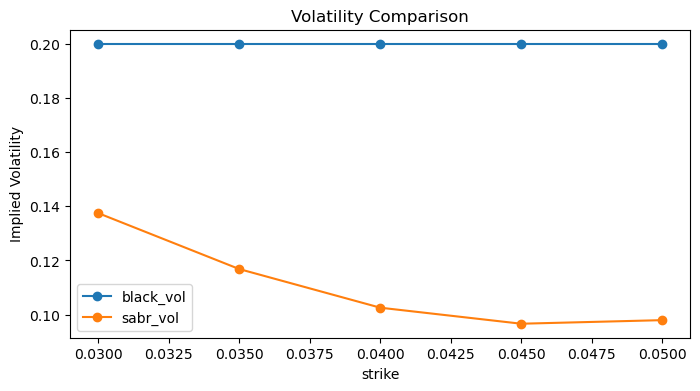

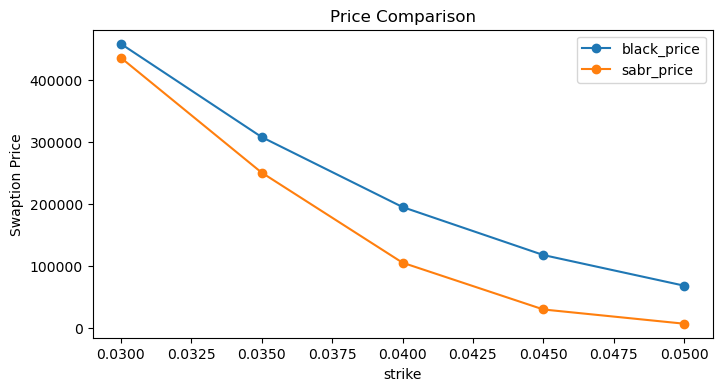

In [5]:
ax = comparison.plot(x='strike', y=['black_vol', 'sabr_vol'], marker='o', figsize=(8, 4), title='Volatility Comparison')
ax.set_ylabel('Implied Volatility')
plt.show()

ax = comparison.plot(x='strike', y=['black_price', 'sabr_price'], marker='o', figsize=(8, 4), title='Price Comparison')
ax.set_ylabel('Swaption Price')
plt.show()

In [6]:
atm_spec = SwaptionSpec(
    notional=notional,
    expiry=expiry,
    tenor=tenor,
    strike=0.0400,
    pay_frequency=pay_frequency,
    option_type='payer',
)

risk_comparison = compare_black_and_sabr_risk(curve, atm_spec, black_vol=flat_black_vol, sabr_params=sabr_params)
pd.DataFrame([
    {
        'model': 'Black',
        'price': risk_comparison.black_price,
        'vol': risk_comparison.black_vol,
        'pv01': risk_comparison.black_risk.pv01,
        'vega_or_alpha_risk': risk_comparison.black_risk.vega,
        'theta': risk_comparison.black_risk.theta,
    },
    {
        'model': 'SABR-adjusted',
        'price': risk_comparison.sabr_price,
        'vol': risk_comparison.sabr_vol,
        'pv01': risk_comparison.sabr_risk.pv01,
        'vega_or_alpha_risk': risk_comparison.sabr_risk.vega,
        'theta': risk_comparison.sabr_risk.theta,
    },
])

,model,price,vol,pv01,vega_or_alpha_risk,theta
0,Black,195368.218347,0.200000,-2344.387197,9.186441e+05,-130.577893
1,SABR-adjusted,105548.051950,0.102537,-2416.856985,4.690410e+06,-59.964659


In [7]:
synthetic_market_vols = [sabr_implied_volatility(forward, strike, expiry, sabr_params) for strike in strikes]
calibration = calibrate_sabr_to_vols(
    forward=forward,
    strikes=strikes,
    expiry=expiry,
    market_vols=synthetic_market_vols,
    beta=0.50,
    initial_guess=(0.0180, -0.10, 0.30),
)

pd.DataFrame({
    'strike': calibration.strikes,
    'market_vol': calibration.market_vols,
    'fitted_vol': calibration.fitted_vols,
})

,strike,market_vol,fitted_vol
0,0.030,0.137420,0.137420
1,0.035,0.116788,0.116788
2,0.040,0.102537,0.102537
3,0.045,0.096621,0.096621
4,0.050,0.097939,0.097939


In [8]:
calibration.params

SabrParams(alpha=0.019999999934315716, beta=0.5, rho=-0.24999998262836687, nu=0.40000000668831914)